## DERIVATIVE PRICING
MODULE 6 | LESSON 4


---


# **LOCAL VOLATILITY MODELS: CEV IN PRACTICE**



|  |  |
|:---|:---|
|**Reading Time** |  55 minutes |
|**Prior Knowledge** | Local-volatility, CEV, Calibration, Implied volatility |
|**Keywords** | CEV model, Calibration|


---


*In the previous lesson, we covered the theoretical framework for one of the most famous parametric local volatility models: the CEV (constant elasticity of variance). In this notebook, we are going to see not only how to implement the CEV model in Python but also how to properly calibrate the model to the implied volatility observed from option market prices.*

*As usual, let's start by importing and installing the necessary libraries.* 

**Note:** Please make sure that you gather data on options chains from Yahoo finance when the U.S. market is open. Otherwise, you may encounter errors in the code when retrieving the data.


In [13]:
import numpy as np
from scipy.stats import ncx2
from sklearn.metrics import mean_squared_error
import pandas as pd
import matplotlib.pyplot as plt

## **1. Reading Option Prices**

\
Next, let's use the same features for extracting options chain data that we have worked on in Lessons 1 and 2 of this module. Please remember to set a maturity date for at least three months after the current date. If not, you may encounter some problems down the road related to the numerical optimization of the model/calibration (this has to do with issues related to the Jacobian).

In [14]:
chain = pd.read_excel("Options_chain_mats.xlsx", sheet_name=['Calls', 'Puts'])
df_call=chain['Calls']
df_put=chain['Puts']
price = 214.23
today = pd.to_datetime('2024-11-11')
df_call['Maturity'] = pd.to_datetime(df_call['Maturity'], format='%Y-%m-%d')
df_put['Maturity'] = pd.to_datetime(df_put['Maturity'], format='%Y-%m-%d')
df_call['Days to maturity'] = (df_call['Maturity'] - today).dt.days
df_put['Days to maturity'] = (df_put['Maturity'] - today).dt.days
df_call = df_call[df_call['Strike']>price*0.8]   # We will only consider those options within a certain range of the current price
df_call = df_call[df_call['Strike']<price*1.2]

df_call = df_call[df_call['Days to maturity']==32]

In [15]:
df_call

,Contract Name,Strike,Last Price,Bid,Ask,Change,% Change,Volume,Open Interest,Implied Volatility,Maturity,Days to maturity
36,IBM241213C00200000,200,15.20,13.80,14.80,0.00,0.0000,1,3,0.1928,2024-12-13,32
37,IBM241213C00205000,205,10.87,10.00,10.40,0.00,0.0000,5,35,0.1773,2024-12-13,32
38,IBM241213C00210000,210,6.90,6.25,6.90,1.02,0.1735,3,45,0.1795,2024-12-13,32
39,IBM241213C00215000,215,4.30,3.80,4.35,0.40,0.1026,15,73,0.1862,2024-12-13,32
40,IBM241213C00220000,220,2.10,1.95,2.50,0.19,0.0995,82,148,0.1881,2024-12-13,32
41,IBM241213C00225000,225,1.10,0.91,2.06,0.05,0.0476,19,31,0.2280,2024-12-13,32
42,IBM241213C00230000,230,0.89,0.09,0.51,0.00,0.0000,4,5,0.1792,2024-12-13,32


With this info, let's plot the market prices for the call options as a function of the different strikes:

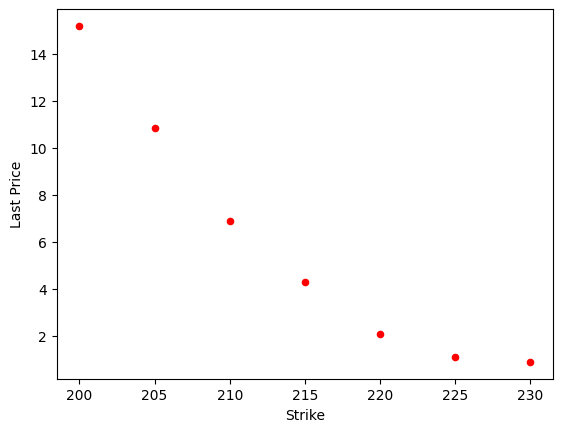

In [16]:
df_call.plot(kind="scatter", x="Strike", y="Last Price", color="red")
plt.show()

Obviously, as the option is more ITM, the premium of the call option increases. The question at this point is, can we replicate these prices with the CEV model?


## **2. Implementing CEV Model with Known Parameters**

Next, let's code our CEV model. As we have seen in the slides from the previous lesson, there are several equivalent specifications for the CEV model. We are going to follow the one in Hsu et al.,2008. (You can check the paper in the [additional readings for the lesson.](https://www.sciencedirect.com/science/article/pii/S0378475407002601?casa_token=x6aiAwSGHU0AAAAA:SWPmucDQ5mjSdSj5lzLRFgoPHGjq0L54Fs84zAmk9WfVjMGREQTJrDj-HGUX6e6iD5nSJcA5*) **Note**: This is not a required reading.)


Hsu et al.'s paper derives the following functional form for the call option price based on the following diffusion for the underlying asset:

$dS = \mu(S,t) dt + \sigma(S, t)dZ$, with:

$\sigma(S, t) = \sigma S^{\beta/2}$, $0\leq \beta < 2$

$\mu(S, t) = rS$

\
Of course, an important assumption is going to be the choice of our parameters $σ$ and and $\beta$. We will refine these choices later, but so far, let's just assume some given parameters. Later on, we will calibrate these parameters to market prices. For now:

- $\sigma = 0.35$
- $\beta = 1.25$

Also, let's assume a value for the risk-free rate:

- $r=0.05$


Mean Squared Error is  3.5007063007996853


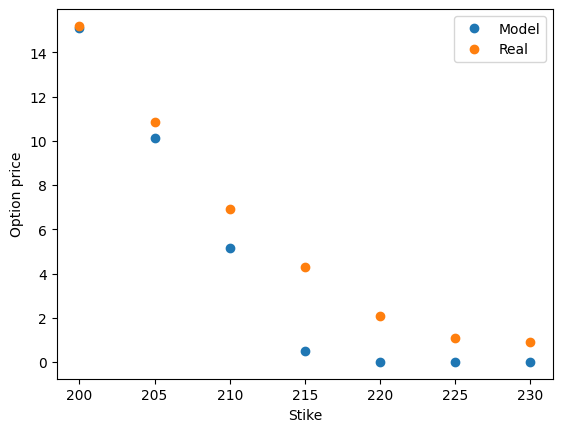

In [17]:
import numpy as np
from scipy.stats import ncx2
from sklearn.metrics import mean_squared_error

# Variables
S0 = price
r = 0.05
Td = 32/365

sigma = 0.90
beta = 0.5

def C(t,K, sigma, beta):
    zb = 2 + 2/(2-beta)
    kappa = 2*r/(sigma**2*(2-beta)*(np.exp(r*(2-beta)*t)-1))
    x = kappa*S0**(2-beta)*np.exp(r*(2-beta)*t)
    y = kappa*K**(2-beta)
    return S0*(1-ncx2.cdf(2*y,zb,2*x))-K*np.exp(-r*t)*(ncx2.cdf(2*x,zb-2,2*y))


test_strikes = df_call['Strike']
modelprices=C(Td,test_strikes, sigma, beta)
realprices = df_call['Last Price']
plt.plot(test_strikes,modelprices,'o', label='Model')
plt.plot(test_strikes,realprices,'o', label='Real')
plt.xlabel('Stike')
plt.ylabel('Option price')
plt.legend()
err = mean_squared_error(modelprices.values, realprices)
print('Mean Squared Error is ',err)

As you can see from the previous graphs, it seems that our model is not doing a very good job in replicating the observed option prices. (You even observe some very negative option prices.) Is it because of the functional form of the model, or is it just that we did not choose our parameters wisely enough?

## **3. CEV Model Calibration**

Finally, what we are going to do is calibrate this model to the option prices observed in the market. In other words, we are going to minimize the error between our CEV model prices and those prices observed in the market. We are going to optimize by changing only the parameters sigma ($\sigma$) and beta ($\beta$) in our CEV model. Hence, our minimization process will output the parameters sigma and beta that make the error with current market prices lower. This whole process is known as **calibration** of the model. 

- Why do we only focus on these parameters? Remember, **risk-neutral valuation**.

We will import the minimize module from scipy in order to proceed with the optimization. For now, we will perform a relatively simple minimization with the default procedures in scipy. In the future, you will see that some more complex calibrations may require devoting more time to the most suitable optimization method.<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

In [18]:
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

We define our error function as the **mean squared error (MSE)** between model and market prices. This error function is what we will actually minimize.

In [19]:
def error(params):
    sigma = params[0]
    beta = params[1]

    modelprices = C(Td, test_strikes, sigma, beta)  # Model price calculation using your C function
    realprices = df_call['Last Price']  # Real prices from your dataframe

    mse = mean_squared_error(modelprices, realprices)
    return mse  # We want to minimize this error

bnds = ((0.2, 2), (0, 1.9))  # Example bounds, adjust as necessary
init_guess = (0.75, 0.5)

# Perform the optimization
res = minimize(error, init_guess, bounds=bnds, options={'disp': True})

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            2     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.57364D+00    |proj g|=  9.84247D-01

At iterate    1    f=  1.09688D-01    |proj g|=  1.29855D+00

At iterate    2    f=  5.77578D-02    |proj g|=  3.90319D-02

At iterate    3    f=  5.77520D-02    |proj g|=  6.67577D-03

At iterate    4    f=  5.77518D-02    |proj g|=  2.38400D-03

At iterate    5    f=  5.77517D-02    |proj g|=  2.72442D-03

At iterate    6    f=  5.77511D-02    |proj g|=  7.11104D-03

At iterate    7    f=  5.77498D-02    |proj g|=  1.51096D-02

At iterate    8    f=  5.77461D-02    |proj g|=  3.03862D-02

At iterate    9    f=  5.77361D-02    |proj g|=  5.41118D-02

At iterate   10    f=  5.73041D-02    |proj g|=  8.85736D-02

At iterate   11    f=  5.72978D-02    |proj g|=  1.26243D-01

At iterate   12    f=  5.71290D-02    |proj g|=  1.09551D-01

At iterate   13    f=  5.6

In [20]:
res.x[0], res.x[1]

(0.2322969041844578, 1.8656863219777975)

You can observe the results from the optimization process. The mean squared error (MSE) is clearly reduced from the initial scenario.

Now, let's see how the results from the model under the optimized parameters ($\sigma$ and $\beta$) look in a graph versus the real market prices:

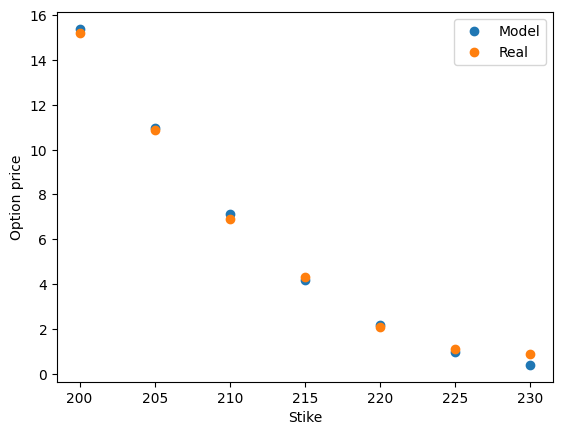

In [21]:
modelprices=C(Td,test_strikes, res.x[0], res.x[1])
realprices = df_call['Last Price']
plt.plot(test_strikes,modelprices,'o', label='Model')
plt.plot(test_strikes,realprices,'o', label='Real')
plt.xlabel('Stike')
plt.ylabel('Option price')
plt.legend()

## **4. Conclusion**

Well done! Now you know how to implement a CEV model and calibrate it to option market prices. This is one of the most important jobs for a quant. In the next module, we will continue to work on these ideas, extending the framework to consider the famous stochastic volatility model of Heston.

**References**


*   Hsu, Y. L. et al. "Constant Elasticity of Variance (CEV) Option Pricing Model: Integration and Detailed Variation." Mathematics and Computers in Simulation, vol. 79, no. 1, 2008, pp. 60–71.



---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
